# Manifold LSRK 3D Snapshots

This notebook is rebuilt from the current repository modules only.
`3D_Spherical_Manifold_DG.ipynb` is reference-only and is not used as implementation code here.
You can edit `R`, `u0`, `alpha0`, `initial_preset`, and `center_xyz` in the parameter cell.
It can compare multiple `n_div` values on one L2-error-vs-time plot, and it can still show step snapshots for a chosen mesh level.

In [7]:
from pathlib import Path
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from experiments.manifold_lsrk_convergence import (
    ManifoldLSRKConvergenceConfig,
    run_manifold_lsrk_convergence,
)
from visualization.manifold_diagnostics import create_manifold_scalar_panel_figure


In [ ]:
# Parameters
field_case = "gaussian"          # "gaussian" or "constant"
constant_value = 1.0
flux_type = "upwind"            # upwind, central, lax_friedrichs
alpha_lf = 1.0
initial_preset = "custom"        # custom, equator, equator_x, equator_y, north_pole, south_pole; overrides center_xyz when not custom
center_xyz = (1.0, 0.0, 0.0)    # direction vector; normalized onto sphere radius R when custom
n_divs = (2, 4, 8, 16)
snapshot_n_div = 8
tf = 6.28
cfl = 1.0
R = 1.0
u0 = 1.0
alpha0 = -np.pi / 4.0
gaussian_width = 1.0 / np.sqrt(10.0)
selected_step = 555              # 0 means initial field, 1 means first accepted RK step, etc.
use_numba = True


In [9]:
history_config = ManifoldLSRKConvergenceConfig(
    mesh_levels=tuple(int(n) for n in n_divs),
    R=float(R),
    u0=float(u0),
    alpha0=float(alpha0),
    center_xyz=tuple(float(v) for v in center_xyz),
    initial_preset=str(initial_preset),
    tf=float(tf),
    cfl=float(cfl),
    gaussian_width=float(gaussian_width),
    field_case=str(field_case),
    flux_type=str(flux_type),
    alpha_lf=float(alpha_lf),
    constant_value=float(constant_value),
    record_history=True,
    record_step_snapshots=False,
    use_numba=bool(use_numba),
    verbose=False,
)

results = run_manifold_lsrk_convergence(history_config)
histories = [row["history"] for row in results if "history" in row]

snapshot_config = ManifoldLSRKConvergenceConfig(
    mesh_levels=(int(snapshot_n_div),),
    R=float(R),
    u0=float(u0),
    alpha0=float(alpha0),
    center_xyz=tuple(float(v) for v in center_xyz),
    initial_preset=str(initial_preset),
    tf=float(tf),
    cfl=float(cfl),
    gaussian_width=float(gaussian_width),
    field_case=str(field_case),
    flux_type=str(flux_type),
    alpha_lf=float(alpha_lf),
    constant_value=float(constant_value),
    record_history=True,
    record_step_snapshots=True,
    use_numba=bool(use_numba),
    verbose=False,
)

snapshot_result = run_manifold_lsrk_convergence(snapshot_config)[0]
snapshot_history = snapshot_result["history"]
step_snapshots = snapshot_result.get("step_snapshots", [])
snapshot_geom = snapshot_result["artifacts"]["geom"]

print("time-history runs:")
for row in results:
    print(
        f"  n_div={row['n_div']} | tf={row['tf']:.6f} | L2={row['L2_error']:.6e} | "
        f"Linf={row['Linf_error']:.6e} | steps={row['nsteps']}"
    )

print()
print(
    f"snapshot mesh n_div={snapshot_result['n_div']} | tf={snapshot_result['tf']:.6f} | "
    f"L2={snapshot_result['L2_error']:.6e} | Linf={snapshot_result['Linf_error']:.6e} | "
    f"steps={snapshot_result['nsteps']} | preset={snapshot_result['initial_preset']} | "
    f"center=({snapshot_result['center_x']:.3f}, {snapshot_result['center_y']:.3f}, {snapshot_result['center_z']:.3f})"
)
print(f"stored step snapshots={len(step_snapshots)}")
print(f"available step range = 0 .. {len(step_snapshots) - 1}")


Finished integration: tf_used=6.280000e+00, nsteps=206, elapsed_sec=0.49s
Finished integration: tf_used=6.280000e+00, nsteps=491, elapsed_sec=2.68s
Finished integration: tf_used=6.280000e+00, nsteps=1108, elapsed_sec=19.09s
Finished integration: tf_used=6.280000e+00, nsteps=2359, elapsed_sec=147.63s
Finished integration: tf_used=6.280000e+00, nsteps=1108, elapsed_sec=19.27s
time-history runs:
  n_div=2 | tf=6.280000 | L2=6.624030e-02 | Linf=2.837807e-01 | steps=206
  n_div=4 | tf=6.280000 | L2=6.298362e-03 | Linf=3.202334e-02 | steps=491
  n_div=8 | tf=6.280000 | L2=2.107017e-04 | Linf=1.540349e-03 | steps=1108
  n_div=16 | tf=6.280000 | L2=1.018877e-05 | Linf=6.624757e-05 | steps=2359

snapshot mesh n_div=8 | tf=6.280000 | L2=2.107017e-04 | Linf=1.540349e-03 | steps=1108
stored step snapshots=1109
available step range = 0 .. 1108


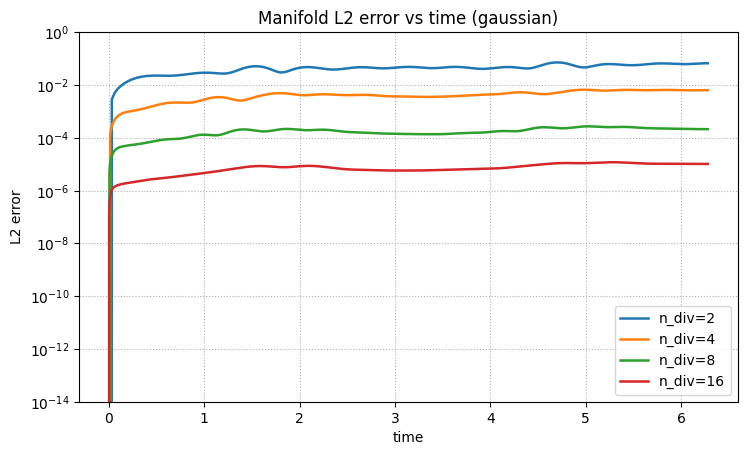

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for history in histories:
    l2 = np.maximum(np.asarray(history["l2"], dtype=float), np.finfo(float).tiny)
    ax.plot(history["times"], l2, linewidth=1.8, label=f"n_div={history['mesh_level']}")
ax.set_yscale("log")
ax.set_xlabel("time")
ax.set_ylabel("L2 error")
ax.set_ylim(bottom=1e-14, top=1e1)
ax.set_title(f"Manifold L2 error vs time ({field_case}, preset={snapshot_result['initial_preset']})")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for history in histories:
    mass_error = np.asarray(history["mass_error"], dtype=float)
    mass_error_plot = np.maximum(np.abs(mass_error), np.finfo(float).tiny)
    ax.plot(history["times"], mass_error_plot, linewidth=1.8, label=f"|mass drift| (n={history['mesh_level']})")
ax.set_yscale("log")
ax.set_xlabel("time")
ax.set_ylabel("|mass error| (log scale)")
ax.set_title(f"Manifold mass drift vs time ({field_case}, preset={snapshot_result['initial_preset']})")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.set_ylim(bottom=1e-14, top=1e1)
ax.legend()
display(fig)
plt.close(fig)

In [12]:
selected_step = 0  # choose the step index for snapshot_n_div

selected_step=0 | used_step=0 | actual=0.000000 | snapshot_n_div=8


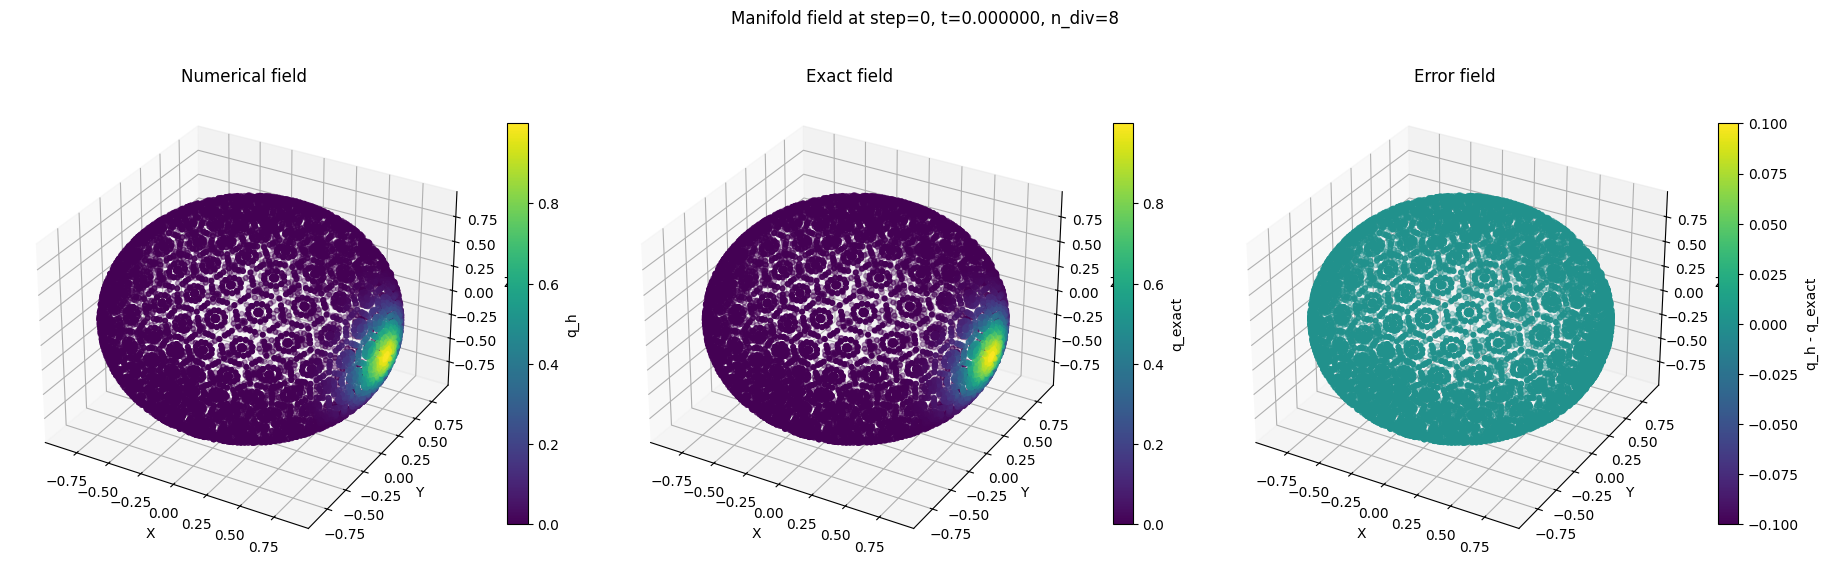

In [13]:
if not step_snapshots:
    raise RuntimeError("No step snapshots were recorded.")

selected_step_clamped = max(0, min(int(selected_step), len(step_snapshots) - 1))
selected = step_snapshots[selected_step_clamped]
print(
    f"selected_step={selected_step} | "
    f"used_step={selected['step_index']} | "
    f"actual={selected['time_actual']:.6f} | "
    f"snapshot_n_div={snapshot_result['n_div']}"
)

panels = [
    {"values": selected["q"], "title": "Numerical field", "label": "q_h"},
]

if str(field_case).strip().lower() == "gaussian":
    panels.append({"values": selected["q_ref"], "title": "Exact field", "label": "q_exact"})
    panels.append({"values": selected["error"], "title": "Error field", "label": "q_h - q_exact"})
else:
    panels.append({"values": selected["error"], "title": "Drift field", "label": "q_h - q_0"})

fig, _axes = create_manifold_scalar_panel_figure(
    snapshot_geom,
    panels,
    suptitle=f"Manifold field at step={selected['step_index']}, t={selected['time_actual']:.6f}, n_div={snapshot_result['n_div']}",
)
display(fig)
plt.close(fig)
